# 🏆 Tournament Simulator — Monte Carlo
**World Cup 2026 Predictor** · We simulate the ENTIRE tournament 10,000 times with the Poisson
goal model as engine, and count how often each team reaches every stage — up to lifting the trophy.

## How it works
1. Every match is simulated by sampling goals from each team's Poisson distribution
   (λ from the Elo gap; hosts get the home-advantage model on home soil).
2. Group standings → 12 winners + 12 runners-up + 8 best third-placed teams qualify.
3. The knockout bracket is wired exactly like the real fixture (placeholders `1A`, `2B`,
   `3A/B/C/D/F`, `W73`...). Drawn knockout games are decided by an Elo-weighted coin flip
   (extra time / penalties).
4. Repeat 10,000 times and count: P(reach R32), P(QF), ... P(champion).

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
rng = np.random.default_rng(42)

# Artifacts
fixture = pd.read_csv("../data/raw/fixture_2026/fixture_2026.csv")  # original order = match numbering
elo_ratings = pd.read_csv("../data/processed/elo_ratings_2026.csv")
ELO = elo_ratings.set_index("team")["elo"].to_dict()
with open("../data/processed/poisson_params.json") as f:
    PARAMS = json.load(f)

# Harmonize fixture names (same fixes as the other notebooks)
name_map = {"USA": "United States", "Bosnia & Herzegovina": "Bosnia and Herzegovina"}
fixture["team1"] = fixture["team1"].replace(name_map)
fixture["team2"] = fixture["team2"].replace(name_map)

HOSTS = {"United States", "Mexico", "Canada"}

group_matches = fixture[fixture["group"].notna()].copy()
ko_matches = fixture[fixture["group"].isna()].copy().reset_index(drop=True)
ko_matches["match_no"] = range(73, 73 + len(ko_matches))  # FIFA numbering: KO matches are 73-104

teams_2026 = sorted(set(group_matches["team1"]) | set(group_matches["team2"]))
print(len(group_matches), "group matches |", len(ko_matches), "knockout matches |", len(teams_2026), "teams")

# Sanity: every team must have an Elo rating
missing_elo = [t for t in teams_2026 if t not in ELO]
print("Teams without Elo rating:", missing_elo if missing_elo else "none ✅")

72 group matches | 32 knockout matches | 48 teams
Teams without Elo rating: none ✅


## 1. The match engine

In [2]:
# Per-simulation Elo uncertainty: ratings are estimates, and form fluctuates.
# Each simulated tournament perturbs every team's rating by N(0, ELO_SIGMA).
ELO_SIGMA = 60
SIM_ELO = dict(ELO)  # overwritten at the start of every simulated tournament

# Venue -> country: home advantage only applies when a host plays IN ITS OWN COUNTRY.
# (Mexico is at home at the Azteca, but a final in New Jersey is neutral ground for them.)
VENUE_COUNTRY = {
    "Mexico City": "Mexico", "Guadalajara (Zapopan)": "Mexico", "Monterrey (Guadalupe)": "Mexico",
    "Toronto": "Canada", "Vancouver": "Canada",
}  # every other venue is in the United States


def venue_country(ground):
    return VENUE_COUNTRY.get(ground, "United States")


def get_lambdas(team1, team2, ground):
    """Expected goals. Home-advantage model only if a team plays in its own country."""
    e1, e2 = SIM_ELO.get(team1, 1500), SIM_ELO.get(team2, 1500)
    country = venue_country(ground)
    if team1 == country and team2 != country:
        p = PARAMS["home_advantage"]
        d = (e1 - e2) / 400
        return np.exp(p["home_intercept"] + p["home_coef"] * d), np.exp(p["away_intercept"] + p["away_coef"] * d)
    if team2 == country and team1 != country:
        p = PARAMS["home_advantage"]
        d = (e2 - e1) / 400  # host as 'home'
        lam_host = np.exp(p["home_intercept"] + p["home_coef"] * d)
        lam_other = np.exp(p["away_intercept"] + p["away_coef"] * d)
        return lam_other, lam_host
    p = PARAMS["neutral"]
    d = (e1 - e2) / 400
    return np.exp(p["home_intercept"] + p["home_coef"] * d), np.exp(p["away_intercept"] + p["away_coef"] * d)


def sim_match(team1, team2, ground):
    """Sample a score from the Poisson model."""
    lam1, lam2 = get_lambdas(team1, team2, ground)
    return rng.poisson(lam1), rng.poisson(lam2)


def ko_winner(team1, team2, ground):
    """Knockout match: if drawn after 90', extra time + penalties decide.
    Shootouts are nearly a coin flip, so the Elo edge is dampened halfway to 50/50."""
    g1, g2 = sim_match(team1, team2, ground)
    if g1 > g2:
        return team1
    if g2 > g1:
        return team2
    e1, e2 = SIM_ELO.get(team1, 1500), SIM_ELO.get(team2, 1500)
    p1_elo = 1 / (1 + 10 ** ((e2 - e1) / 400))
    p1 = 0.5 + 0.5 * (p1_elo - 0.5)  # dampened towards 50/50
    return team1 if rng.random() < p1 else team2

# Quick tests: Mexico at the Azteca vs Mexico at a neutral US venue
print("Mexico-South Africa lambdas at Mexico City:", tuple(round(x, 2) for x in get_lambdas("Mexico", "South Africa", "Mexico City")))
print("Mexico-South Africa lambdas in Atlanta:    ", tuple(round(x, 2) for x in get_lambdas("Mexico", "South Africa", "Atlanta")))

Mexico-South Africa lambdas at Mexico City: (np.float64(2.55), np.float64(0.53))
Mexico-South Africa lambdas in Atlanta:     (np.float64(2.61), np.float64(0.67))


## 2. Group stage, standings and best thirds

In [3]:
GROUP_FIXTURES = {
    g: list(zip(df["team1"], df["team2"], df["ground"]))
    for g, df in group_matches.groupby("group")
}

def sim_group(group_name):
    """Simulate one group. Returns standings: list of (team, pts, gd, gf) sorted."""
    stats = {}
    for t1, t2, ground in GROUP_FIXTURES[group_name]:
        for t in (t1, t2):
            stats.setdefault(t, [0, 0, 0])  # pts, gd, gf
        g1, g2 = sim_match(t1, t2, ground)
        stats[t1][1] += g1 - g2; stats[t1][2] += g1
        stats[t2][1] += g2 - g1; stats[t2][2] += g2
        if g1 > g2:
            stats[t1][0] += 3
        elif g2 > g1:
            stats[t2][0] += 3
        else:
            stats[t1][0] += 1; stats[t2][0] += 1
    # FIFA tiebreakers approximated: points, goal difference, goals for, then lots (random)
    return sorted(stats.items(), key=lambda kv: (kv[1][0], kv[1][1], kv[1][2], rng.random()), reverse=True)


def assign_thirds(slots, qualified_thirds):
    """Match the 8 best thirds to the bracket slots respecting allowed groups (backtracking)."""
    slot_ids = list(slots.keys())

    def backtrack(i, remaining, assignment):
        if i == len(slot_ids):
            return assignment
        sid = slot_ids[i]
        for grp in list(remaining):
            if grp in slots[sid]:
                result = backtrack(i + 1, remaining - {grp}, {**assignment, sid: grp})
                if result:
                    return result
        return None

    result = backtrack(0, set(qualified_thirds.keys()), {})
    if result is None:  # extremely rare: relax constraints
        result = dict(zip(slot_ids, qualified_thirds.keys()))
    return {sid: qualified_thirds[grp] for sid, grp in result.items()}

## 3. Full-tournament simulation

In [4]:
# Third-place slots in the bracket: placeholder -> allowed groups
THIRD_SLOTS = {}
for ph in pd.concat([ko_matches["team1"], ko_matches["team2"]]):
    if ph.startswith("3"):
        THIRD_SLOTS[ph] = set(ph[1:].split("/"))

KO_LIST = list(zip(ko_matches["match_no"], ko_matches["round"], ko_matches["team1"], ko_matches["team2"], ko_matches["ground"]))
STAGES = ["R32", "R16", "QF", "SF", "Final", "Champion"]
ROUND_TO_STAGE = {"Round of 32": "R16", "Round of 16": "QF", "Quarter-final": "SF", "Semi-final": "Final"}


def sim_tournament():
    """One full tournament. Returns dict: team -> furthest stage reached."""
    # Fresh Elo perturbation for this tournament: each team's 'true form' this month
    global SIM_ELO
    SIM_ELO = {t: ELO.get(t, 1500) + rng.normal(0, ELO_SIGMA) for t in teams_2026}

    reached = {}
    slots = {}        # placeholder -> team  ('1A', '2B', 'W73', ...)
    thirds_pool = {}  # group letter -> (team, pts, gd, gf)

    # Group stage
    for g in GROUP_FIXTURES:
        standings = sim_group(g)
        letter = g[-1]
        slots[f"1{letter}"] = standings[0][0]
        slots[f"2{letter}"] = standings[1][0]
        t3, s3 = standings[2]
        thirds_pool[letter] = (t3, s3[0], s3[1], s3[2])
        reached[standings[0][0]] = "R32"
        reached[standings[1][0]] = "R32"

    # Best 8 thirds
    ranked = sorted(thirds_pool.items(), key=lambda kv: (kv[1][1], kv[1][2], kv[1][3], rng.random()), reverse=True)
    qualified_thirds = {grp: data[0] for grp, data in ranked[:8]}
    for team in qualified_thirds.values():
        reached[team] = "R32"
    slots.update(assign_thirds(THIRD_SLOTS, qualified_thirds))

    # Knockout rounds
    finalists = []
    for match_no, rnd, ph1, ph2, ground in KO_LIST:
        if rnd in ("Match for third place",):
            continue
        t1, t2 = slots[ph1], slots[ph2]
        if rnd == "Final":
            winner = ko_winner(t1, t2, ground)
            reached[winner] = "Champion"
            reached[t1 if winner == t2 else t2] = "Final"
            continue
        winner = ko_winner(t1, t2, ground)
        loser = t1 if winner == t2 else t2
        slots[f"W{match_no}"] = winner
        slots[f"L{match_no}"] = loser
        reached[winner] = ROUND_TO_STAGE[rnd]
        if rnd == "Semi-final":
            finalists.append(winner)

    return reached

# Smoke test: one tournament
test = sim_tournament()
champ = [t for t, s in test.items() if s == "Champion"]
print("Sample simulated champion:", champ[0])

Sample simulated champion: Spain


In [5]:
N_SIMS = 10_000
STAGE_ORDER = {"R32": 0, "R16": 1, "QF": 2, "SF": 3, "Final": 4, "Champion": 5}

counts = {t: np.zeros(6, dtype=int) for t in teams_2026}

for _ in range(N_SIMS):
    reached = sim_tournament()
    for team, stage in reached.items():
        # Reaching a stage implies reaching all previous ones
        counts[team][: STAGE_ORDER[stage] + 1] += 1

odds = pd.DataFrame(
    {t: c / N_SIMS * 100 for t, c in counts.items()},
    index=["R32", "R16", "QF", "SF", "Final", "Champion"],
).T.round(1)
odds = odds.sort_values("Champion", ascending=False)

print(f"World Cup 2026 — odds from {N_SIMS:,} simulated tournaments\n")
print(odds.head(16).to_string())

World Cup 2026 — odds from 10,000 simulated tournaments

                R32   R16    QF    SF  Final  Champion
Spain          99.8  79.5  60.3  48.7   34.2      23.8
Argentina      98.4  72.0  56.2  43.1   28.7      17.0
France         96.0  73.3  46.1  31.0   17.6       9.7
England        98.0  67.6  36.7  21.4   11.5       5.6
Brazil         95.3  56.1  34.5  19.2    9.5       4.3
Germany        96.9  60.3  31.2  18.4    8.6       4.2
Portugal       94.1  62.1  33.9  17.1    8.9       4.1
Mexico         97.2  70.5  39.9  17.4    7.6       3.1
Netherlands    93.9  49.9  30.7  15.0    6.6       3.1
Morocco        92.8  50.2  30.3  15.9    7.2       3.0
Colombia       91.1  57.0  28.4  13.7    6.6       2.9
United States  83.0  55.2  29.3  13.8    6.7       2.9
Ecuador        95.2  55.0  27.0  14.4    6.3       2.4
Japan          91.0  44.4  25.7  12.3    5.4       2.3
Turkey         76.6  49.0  24.1   9.6    4.0       1.8
Croatia        91.0  45.4  18.2   8.7    3.5       1.3


In [6]:
# Save artifact for the dashboard
odds.reset_index().rename(columns={"index": "team"}).to_csv(
    "../data/processed/tournament_odds.csv", index=False
)
print("Saved -> tournament_odds.csv")

Saved -> tournament_odds.csv


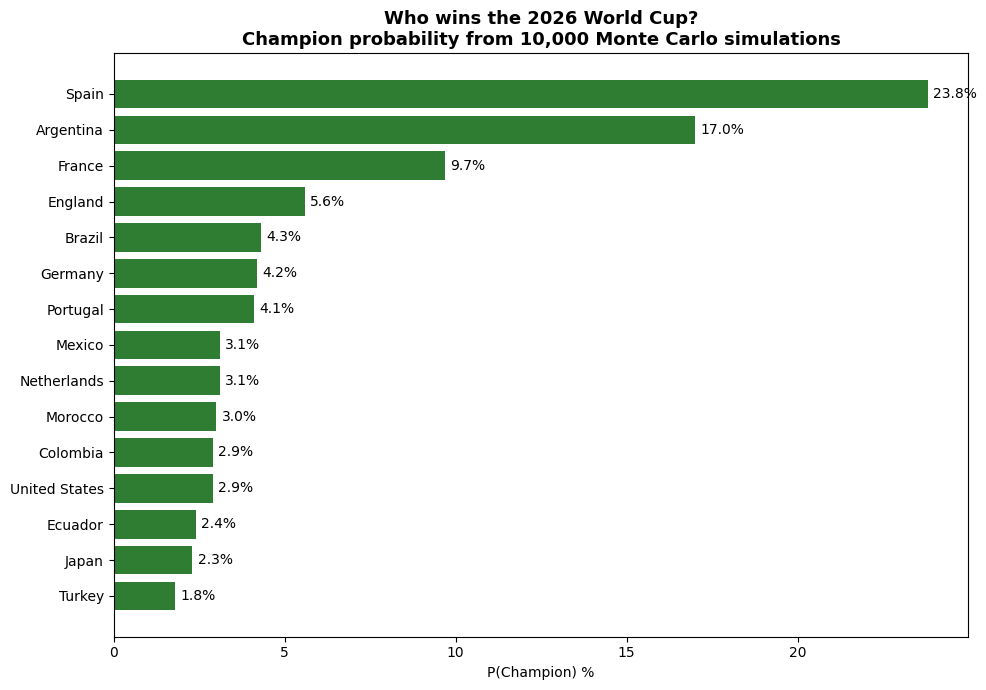

In [7]:
top15 = odds.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top15.index[::-1], top15["Champion"][::-1], color="#2E7D32")
for i, (team, row) in enumerate(top15[::-1].iterrows()):
    plt.text(row["Champion"] + 0.15, i, f"{row['Champion']:.1f}%", va="center", fontsize=10)
plt.title(f"Who wins the 2026 World Cup?\nChampion probability from {N_SIMS:,} Monte Carlo simulations",
          fontsize=13, fontweight="bold")
plt.xlabel("P(Champion) %")
plt.tight_layout()
plt.savefig("../data/processed/champion_odds.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Projected bracket — the single most likely tournament
Instead of rolling dice, we now run the tournament **deterministically**: group standings by
expected points, and in every knockout tie the team with the higher win probability advances.
This is "the modal World Cup" — the one the model considers most likely.

In [8]:
def match_probs(t1, t2, ground):
    """P(t1 wins), P(draw), P(t2 wins) from the Poisson matrix (no Elo noise)."""
    global SIM_ELO
    SIM_ELO = dict(ELO)  # deterministic: no per-sim noise
    lam1, lam2 = get_lambdas(t1, t2, ground)
    from scipy.stats import poisson as pois
    M = np.outer([pois.pmf(i, lam1) for i in range(11)], [pois.pmf(j, lam2) for j in range(11)])
    return np.tril(M, -1).sum(), np.trace(M), np.triu(M, 1).sum()


def project_group(group_name):
    """Standings by expected points (tiebreak: expected goal difference)."""
    exp = {}
    for t1, t2, ground in GROUP_FIXTURES[group_name]:
        p1, pd_, p2 = match_probs(t1, t2, ground)
        lam1, lam2 = get_lambdas(t1, t2, ground)
        for t in (t1, t2):
            exp.setdefault(t, [0.0, 0.0])  # exp_pts, exp_gd
        exp[t1][0] += 3 * p1 + pd_; exp[t1][1] += lam1 - lam2
        exp[t2][0] += 3 * p2 + pd_; exp[t2][1] += lam2 - lam1
    return sorted(exp.items(), key=lambda kv: (kv[1][0], kv[1][1]), reverse=True)


# Project groups
proj_slots, proj_thirds, group_tables = {}, {}, {}
for g in GROUP_FIXTURES:
    standings = project_group(g)
    letter = g[-1]
    group_tables[letter] = [(t, round(s[0], 2)) for t, s in standings]
    proj_slots[f"1{letter}"] = standings[0][0]
    proj_slots[f"2{letter}"] = standings[1][0]
    proj_thirds[letter] = (standings[2][0], standings[2][1][0], standings[2][1][1])

# Best 8 projected thirds
ranked_thirds = sorted(proj_thirds.items(), key=lambda kv: (kv[1][1], kv[1][2]), reverse=True)
qualified = {grp: data[0] for grp, data in ranked_thirds[:8]}
proj_slots.update(assign_thirds(THIRD_SLOTS, qualified))

# Project knockouts: higher win probability advances (draw prob split by Elo edge)
bracket = []
for match_no, rnd, ph1, ph2, ground in KO_LIST:
    if rnd == "Match for third place":
        continue
    t1, t2 = proj_slots[ph1], proj_slots[ph2]
    p1, pd_, p2 = match_probs(t1, t2, ground)
    e1, e2 = ELO.get(t1, 1500), ELO.get(t2, 1500)
    elo_share = 1 / (1 + 10 ** ((e2 - e1) / 400))
    win1 = p1 + pd_ * (0.5 + 0.5 * (elo_share - 0.5))
    winner = t1 if win1 >= 0.5 else t2
    proj_slots[f"W{match_no}"] = winner
    bracket.append({"match_no": int(match_no), "round": rnd, "team1": t1, "team2": t2,
                    "winner": winner, "win_prob": round(max(win1, 1 - win1) * 100, 1),
                    "ph1": ph1, "ph2": ph2})

champion = bracket[-1]["winner"]
print(f"PROJECTED CHAMPION: {champion}\n")
for b in bracket:
    star = " 🏆" if b["round"] == "Final" else ""
    print(f"[{b['round']:<13}] {b['team1']:<15} vs {b['team2']:<15} -> {b['winner']} ({b['win_prob']}%){star}")

PROJECTED CHAMPION: Spain

[Round of 32  ] South Korea     vs Switzerland     -> Switzerland (50.7%)
[Round of 32  ] Germany         vs Paraguay        -> Germany (71.9%)
[Round of 32  ] Netherlands     vs Morocco         -> Netherlands (52.5%)
[Round of 32  ] Brazil          vs Japan           -> Brazil (59.0%)
[Round of 32  ] France          vs Scotland        -> France (85.4%)
[Round of 32  ] Ecuador         vs Norway          -> Ecuador (62.1%)
[Round of 32  ] Mexico          vs Ivory Coast     -> Mexico (80.7%)
[Round of 32  ] England         vs Austria         -> England (77.3%)
[Round of 32  ] United States   vs Senegal         -> United States (61.2%)
[Round of 32  ] Belgium         vs Czech Republic  -> Belgium (69.9%)
[Round of 32  ] Colombia        vs Croatia         -> Colombia (60.7%)
[Round of 32  ] Spain           vs Algeria         -> Spain (89.3%)
[Round of 32  ] Canada          vs Egypt           -> Canada (70.0%)
[Round of 32  ] Argentina       vs Uruguay         -> 

In [9]:
# Save projected bracket artifact for the dashboard
import json as _json
with open("../data/processed/projected_bracket.json", "w", encoding="utf-8") as f:
    _json.dump({"champion": champion, "bracket": bracket}, f, ensure_ascii=False, indent=1)
print("Saved -> projected_bracket.json")

Saved -> projected_bracket.json


### Drawing the bracket

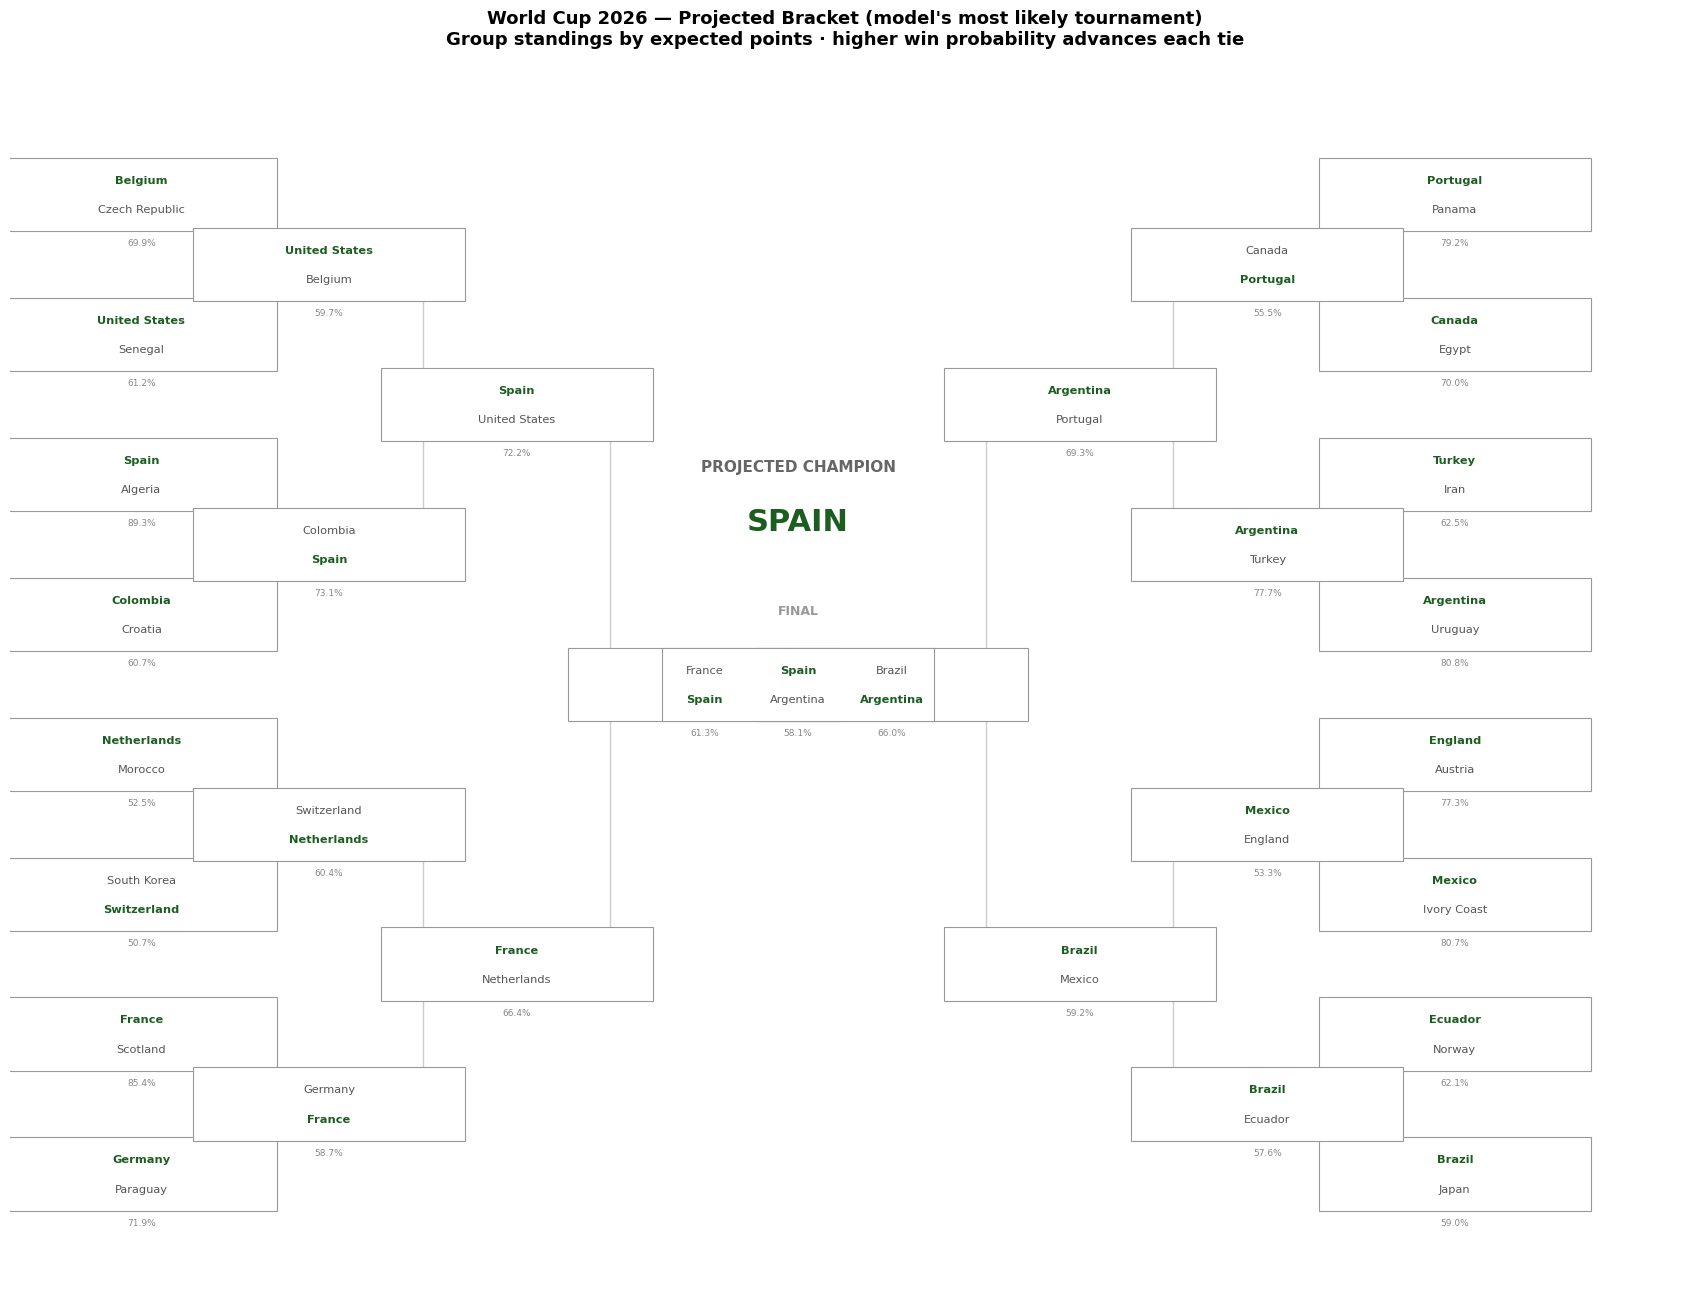

Saved -> projected_bracket.png


In [10]:
# Two-sided bracket image (semifinal 101 subtree on the left, 102 on the right)
info = {b["match_no"]: b for b in bracket}
FINAL_NO = max(info.keys())
DEPTH = {"Round of 32": 0, "Round of 16": 1, "Quarter-final": 2, "Semi-final": 3}


def children(m):
    return [int(p[1:]) for p in (m["ph1"], m["ph2"]) if p.startswith("W") and int(p[1:]) in info]


pos = {}
leaf_y = {"L": 0, "R": 0}


def layout(match_no, side):
    m = info[match_no]
    ch = children(m)
    if not ch:  # Round-of-32 leaf
        y = leaf_y[side] * 2.0
        leaf_y[side] += 1
    else:
        y = np.mean([layout(c, side) for c in ch])
    depth = DEPTH[m["round"]]
    x = depth if side == "L" else 7 - depth
    pos[match_no] = (x, y)
    return y


final = info[FINAL_NO]
sf_left, sf_right = children(final)  # SF match numbers
layout(sf_left, "L")
layout(sf_right, "R")
pos[FINAL_NO] = (3.5, (pos[sf_left][1] + pos[sf_right][1]) / 2)

GREEN, GRAY = "#1B5E20", "#555555"
fig, ax = plt.subplots(figsize=(17, 13))
ax.set_xlim(-0.7, 8.2)
ax.set_ylim(-1.5, 15.8)
ax.axis("off")
BOX_W, BOX_H = 1.45, 1.05


def draw_match(match_no):
    m = info[match_no]
    x, y = pos[match_no]
    ax.add_patch(plt.Rectangle((x - BOX_W / 2, y - BOX_H / 2), BOX_W, BOX_H,
                               facecolor="white", edgecolor="#999999", linewidth=0.8, zorder=3))
    for i, t in enumerate([m["team1"], m["team2"]]):
        is_winner = t == m["winner"]
        ax.text(x, y + 0.21 - i * 0.42, t, ha="center", va="center", fontsize=8.2,
                fontweight="bold" if is_winner else "normal",
                color=GREEN if is_winner else GRAY, zorder=4)
    ax.text(x, y - 0.69, f"{m['win_prob']}%", ha="center", va="center",
            fontsize=6.5, color="#888888", zorder=4)


def draw_links(match_no):
    for c in children(info[match_no]):
        x1, y1 = pos[c]
        x2, y2 = pos[match_no]
        xm = (x1 + x2) / 2
        ax.plot([x1, xm, xm, x2], [y1, y1, y2, y2], color="#CCCCCC", linewidth=1.0, zorder=1)
        draw_links(c)


draw_links(FINAL_NO)
for mn in pos:
    draw_match(mn)

# Champion banner
champ_x, champ_y = 3.5, pos[FINAL_NO][1] + 2.2
ax.text(champ_x, champ_y + 0.85, "PROJECTED CHAMPION", ha="center", fontsize=11,
        color="#666666", fontweight="bold")
ax.text(champ_x, champ_y, champion.upper(), ha="center", fontsize=22,
        color=GREEN, fontweight="bold")
ax.text(champ_x, pos[FINAL_NO][1] + 1.0, "FINAL", ha="center", fontsize=9,
        color="#999999", fontweight="bold")

ax.set_title("World Cup 2026 — Projected Bracket (model's most likely tournament)\n"
             "Group standings by expected points · higher win probability advances each tie",
             fontsize=13, fontweight="bold", pad=18)
plt.tight_layout()
plt.savefig("../data/processed/projected_bracket.png", dpi=180, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved -> projected_bracket.png")

## Conclusions

- The simulator turns a **match-level model into tournament-level insights**: every team's
  probability of reaching each stage, computed from 10,000 simulated World Cups.
- Knockout draws are decided by an Elo-weighted coin flip — a simplification of extra time
  and penalty shootouts.
- The bracket is wired exactly like the real fixture, including the best-third allocation
  constraints (solved per simulation with backtracking).
- These odds will be **re-computed after every matchday** with updated Elo ratings — expect
  big swings when favourites stumble.

**Calibration:** a first version without rating uncertainty gave Spain a 28.8% title chance —
roughly double the betting market (~15%). Treating Elo as exact truth makes favourites
overconfident. Adding per-simulation rating noise (σ=60 Elo points, modelling estimation error
and form fluctuation) and dampening penalty shootouts towards 50/50 brings the odds closer
to market consensus while staying principled.

**Venue-aware host advantage:** a first version gave hosts home advantage in every match,
which made Mexico 4th favourite — but the semi-finals and final are played in the USA, where
Mexico is NOT at home. The engine now checks each match's actual venue and only applies the
home-advantage model when a team plays in its own country.

**Caveats:** group tiebreakers are approximated (points/GD/GF then lots); Elo ratings are
frozen at tournament start until we update them with real results.